# Лабораторная работа 1. Вариант 6 — Умный город (Smart City)
## Полное решение: Часть 1 + Часть 2
### Формализация постановок задач исследования КИС

---

## **Содержание**

### **ЧАСТЬ 1. Парето-оптимизация конфигураций ПК**
1. Постановка задачи
2. Загрузка данных
3. Фильтрация по требованиям Smart City
4. Парето-оптимизация
5. Нормирование критериев
6. Идеальная точка и расстояние
7. Линейная свертка с приоритетами

### **ЧАСТЬ 2. Масштабирование инфраструктуры**
8. Определение весовых коэффициентов для сегментов
9. Расчет критериев предпочтения для каждого сегмента
10. Требования к сетевым интерфейсам (Wi-Fi и Bluetooth)
11. Требования к GPU для Vision сегмента
12. Двухуровневая оптимизация
13. Визуализация результатов
14. Выводы

---
# **ЧАСТЬ 1. ПАРЕТО-ОПТИМИЗАЦИЯ КОНФИГУРАЦИЙ ПК**
---

## 1. Постановка задачи (Часть 1)

Требуется подобрать конфигурации ПК для развёртывания инфраструктуры **Умного города (Smart City)**:

**Требования к конструктивным параметрам:**

1. **Распределённая сеть датчиков** — поддержка множества подключений, сетевые интерфейсы.
2. **Edge computing на периферии** — локальная обработка данных, достаточная вычислительная мощность.
3. **Централизованная аналитика** — серверы для агрегации и анализа данных с датчиков.
4. **Долгий срок службы (5-7 лет)** — надёжное оборудование, энергоэффективность.

**Количественные ограничения:**

- CPU_Cores ≥ 8 (параллельная обработка данных с датчиков).
- RAM_GB ≥ 32 (буферы для потоковых данных).
- Storage_GB ≥ 500 (хранение данных датчиков).
- Storage_Type ∈ {SSD, NVMe} (надёжность, скорость записи).
- Condition ∈ {Good, Like New, New} (долгий срок службы).
- Power_Consumption_W ≤ 300 (энергоэффективность).
- Price_USD ≤ 4000 (ограничения по бюджету для массового развёртывания).

---
## 2. Загрузка данных

In [ ]:
# Загрузка необходимых библиотек
if (!require(readxl)) install.packages("readxl", repos = "https://cloud.r-project.org")
if (!require(dplyr)) install.packages("dplyr", repos = "https://cloud.r-project.org")
if (!require(ggplot2)) install.packages("ggplot2", repos = "https://cloud.r-project.org")
if (!require(tidyr)) install.packages("tidyr", repos = "https://cloud.r-project.org")

library(readxl)
library(dplyr)
library(ggplot2)
library(tidyr)

# Загрузка данных из CSV файла
Data <- read.csv("computer_dataset_1000.csv", sep = ",")
View(Data)
cat("Размер датасета:", nrow(Data), "x", ncol(Data), "\n")

ID,CPU_Frequency_GHz,CPU_Cores,CPU_Brand,CPU_Generation,RAM_GB,Storage_GB,Storage_Type,GPU_Type,GPU_Model,⋯,Brand,Model,Purchase_Date,Age_Days,Condition,Price_USD,Power_Consumption_W,Weight_kg,Screen_Size_inch,Case_Type
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PC-0001,2.64,4,Intel Core i9,11,16,1000,SSD,Dedicated,AMD Radeon RX 6600,⋯,Apple,Inspiron 1409,2023-07-29,930,Good,1159,238,NA,NA,Full Tower
PC-0002,5.00,8,AMD Ryzen 3,8,16,2000,NVMe,Integrated,Intel Iris Xe,⋯,Apple,ZBook 5012,2023-09-14,883,Good,1616,218,NA,NA,
PC-0003,4.10,12,AMD Ryzen 9,12,256,512,NVMe,Dedicated,NVIDIA RTX 3060,⋯,Lenovo,EliteBook 3286,2025-06-06,252,Like New,2568,393,3.1,13.3,
PC-0004,3.55,10,Intel Core i7,11,16,1000,HDD,Integrated,Intel UHD,⋯,Samsung,Inspiron 9935,2025-10-01,135,Like New,1619,118,NA,27.0,
PC-0005,1.74,12,AMD Ryzen 9,8,16,1000,HDD,Integrated,Intel UHD,⋯,Dell,Inspiron 7912,2024-09-08,523,New,1570,128,NA,NA,Small Form Factor
PC-0006,1.74,8,Intel Core i3,14,128,2000,HDD,Dedicated,NVIDIA RTX 4080,⋯,HP,XPS 1488,2023-12-02,804,Good,2285,324,NA,16.0,
PC-0007,1.34,8,AMD Ryzen 7,10,32,4000,SSD,Dedicated,NVIDIA RTX 3060,⋯,Dell,Inspiron 4582,2024-04-24,660,Good,2093,296,NA,NA,Full Tower
PC-0008,4.65,12,AMD Ryzen 9,7,128,128,SSD,Dedicated,NVIDIA RTX 3060,⋯,Lenovo,EliteBook 9279,2025-03-31,NA,Fair,2445,325,1.0,14.0,
PC-0009,3.56,4,Intel Core i5,11,8,1000,SSD,Integrated,Intel UHD,⋯,HP,XPS 4257,2025-11-25,80,Fair,1156,84,3.0,13.3,


Размер датасета: 1000 x 31 


---
## 3. Фильтрация по требованиям Smart City

In [ ]:
# Отбор по критериям варианта 6 (Умный город, Smart City)
C <- Data$ID[
  (Data$CPU_Cores >= 8) &
  (Data$RAM_GB >= 32) &
  (Data$Storage_GB >= 500) &
  (Data$Price_USD <= 4000) &
  (Data$Storage_Type %in% c("SSD", "NVMe")) &
  (Data$Condition %in% c("Good", "Like New", "New")) &
  (!is.na(Data$Power_Consumption_W)) &
  (Data$Power_Consumption_W <= 300)
]
C

[1] "PC-0007" "PC-0015" "PC-0018" "PC-0046" "PC-0052" "PC-0057" "PC-0084"
 [8] "PC-0091" "PC-0102" "PC-0126" "PC-0141" "PC-0146" "PC-0149" "PC-0153"
[15] "PC-0161" "PC-0179" "PC-0180" "PC-0206" "PC-0219" "PC-0221" "PC-0231"
[22] "PC-0262" "PC-0278" "PC-0294" "PC-0312" "PC-0338" NA        "PC-0349"
[29] "PC-0352" "PC-0407" "PC-0415" "PC-0432" "PC-0441" "PC-0453" "PC-0457"
[36] "PC-0460" "PC-0478" "PC-0495" "PC-0497" "PC-0500" "PC-0548" "PC-0557"
[43] "PC-0571" "PC-0580" "PC-0583" "PC-0591" "PC-0596" "PC-0628" "PC-0649"
[50] "PC-0657" "PC-0661" "PC-0675" "PC-0680" "PC-0692" "PC-0719" "PC-0741"
[57] "PC-0751" "PC-0767" "PC-0785" "PC-0829" "PC-0831" "PC-0832" "PC-0835"
[64] "PC-0849" "PC-0861" "PC-0864" "PC-0866" "PC-0871" "PC-0876" "PC-0905"
[71] "PC-0916" "PC-0917" "PC-0923" "PC-0927" "PC-0929" "PC-0931" "PC-0935"
[78] "PC-0944" "PC-0953" "PC-0956" "PC-0957" "PC-0993" "PC-0996"

In [ ]:
# Убираем пропущенные значения
C <- C[!is.na(C)]
cat("Количество конфигураций, прошедших отбор:", length(C), "\n")
C

Количество конфигураций, прошедших отбор: 82 


[1] "PC-0007" "PC-0015" "PC-0018" "PC-0046" "PC-0052" "PC-0057" "PC-0084"
 [8] "PC-0091" "PC-0102" "PC-0126" "PC-0141" "PC-0146" "PC-0149" "PC-0153"
[15] "PC-0161" "PC-0179" "PC-0180" "PC-0206" "PC-0219" "PC-0221" "PC-0231"
[22] "PC-0262" "PC-0278" "PC-0294" "PC-0312" "PC-0338" "PC-0349" "PC-0352"
[29] "PC-0407" "PC-0415" "PC-0432" "PC-0441" "PC-0453" "PC-0457" "PC-0460"
[36] "PC-0478" "PC-0495" "PC-0497" "PC-0500" "PC-0548" "PC-0557" "PC-0571"
[43] "PC-0580" "PC-0583" "PC-0591" "PC-0596" "PC-0628" "PC-0649" "PC-0657"
[50] "PC-0661" "PC-0675" "PC-0680" "PC-0692" "PC-0719" "PC-0741" "PC-0751"
[57] "PC-0767" "PC-0785" "PC-0829" "PC-0831" "PC-0832" "PC-0835" "PC-0849"
[64] "PC-0861" "PC-0864" "PC-0866" "PC-0871" "PC-0876" "PC-0905" "PC-0916"
[71] "PC-0917" "PC-0923" "PC-0927" "PC-0929" "PC-0931" "PC-0935" "PC-0944"
[78] "PC-0953" "PC-0956" "PC-0957" "PC-0993" "PC-0996"

---
## 4. Формирование датафрейма для Парето-оптимизации

In [ ]:
F <- data.frame(
  Data$CPU_Cores[Data$ID %in% C],
  Data$RAM_GB[Data$ID %in% C],
  Data$Storage_GB[Data$ID %in% C],
  1 / Data$Price_USD[Data$ID %in% C],
  1 / Data$Power_Consumption_W[Data$ID %in% C]
)
colnames(F) <- c("CPU_Cores", "RAM_GB", "Storage_GB", "Inv_Price_USD", "Inv_Power_W")
rownames(F) <- C
View(F)

,CPU_Cores,RAM_GB,Storage_GB,Inv_Price_USD,Inv_Power_W
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PC-0007,8,32,4000,0.0004777831,0.003378378
PC-0015,10,32,1000,0.0007390983,0.003623188
PC-0018,8,256,512,0.0003866976,0.004484305
PC-0046,8,64,2000,0.0005668934,0.007042254
PC-0052,8,32,512,0.0007401925,0.009009009
PC-0057,10,32,1000,0.0006548788,0.007936508
PC-0084,12,256,1000,0.0003930818,0.004032258
PC-0091,24,128,512,0.0003486750,0.004184100
PC-0102,32,32,2000,0.0002974420,0.004065041


---
## 5. Парето-оптимизация

In [ ]:
# Проверка: X доминирует по Парето Y (X >_p Y)
DPareto <- function(X, Y) {
  p <- TRUE
  l <- FALSE
  i <- 1
  while (p & (i <= length(X))) {
    if (X[i] < Y[i]) p <- FALSE
    if (X[i] > Y[i]) l <- TRUE
    i <- i + 1
  }
  if (!p | !l) return(FALSE)
  else return(TRUE)
}

result <- c()
for (i in c(1:length(rownames(F)))) {
  p <- TRUE
  for (j in c(1:length(rownames(F)))) {
    if (DPareto(F[j, ], F[i, ]))
      p <- FALSE
  }
  if (p) result <- c(result, rownames(F)[i])
}
cat("Парето-оптимальные конфигурации:", length(result), "\n")
result

Парето-оптимальные конфигурации: 46 


[1] "PC-0015" "PC-0046" "PC-0057" "PC-0084" "PC-0091" "PC-0102" "PC-0126"
 [8] "PC-0146" "PC-0149" "PC-0153" "PC-0161" "PC-0179" "PC-0180" "PC-0206"
[15] "PC-0221" "PC-0231" "PC-0262" "PC-0312" "PC-0349" "PC-0352" "PC-0407"
[22] "PC-0432" "PC-0453" "PC-0478" "PC-0580" "PC-0591" "PC-0657" "PC-0675"
[29] "PC-0719" "PC-0751" "PC-0785" "PC-0829" "PC-0835" "PC-0849" "PC-0866"
[36] "PC-0871" "PC-0876" "PC-0916" "PC-0917" "PC-0923" "PC-0927" "PC-0935"
[43] "PC-0953" "PC-0956" "PC-0957" "PC-0993"

In [ ]:
FF <- data.frame(
  Data$CPU_Cores[Data$ID %in% result],
  Data$RAM_GB[Data$ID %in% result],
  Data$Storage_GB[Data$ID %in% result],
  Data$Price_USD[Data$ID %in% result],
  Data$Power_Consumption_W[Data$ID %in% result]
)
colnames(FF) <- c("CPU_Cores", "RAM_GB", "Storage_GB", "Price_USD", "Power_Consumption_W")
rownames(FF) <- result
FF

,CPU_Cores,RAM_GB,Storage_GB,Price_USD,Power_Consumption_W
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PC-0015,10,32,1000,1353,276
PC-0046,8,64,2000,1764,142
PC-0057,10,32,1000,1527,126
PC-0084,12,256,1000,2544,248
PC-0091,24,128,512,2868,239
PC-0102,32,32,2000,3362,246
PC-0126,8,64,1000,1748,132
PC-0146,12,128,512,1947,179
PC-0149,12,32,2000,1741,296


---
## 6. Нормирование критериев

In [ ]:
mmax <- max(FF$CPU_Cores)
mmin <- min(FF$CPU_Cores)
CPU_Cores_norm <- (FF$CPU_Cores - mmin) * 100 / (mmax - mmin)

mmax <- max(FF$RAM_GB)
mmin <- min(FF$RAM_GB)
RAM_GB_norm <- (FF$RAM_GB - mmin) * 100 / (mmax - mmin)

mmax <- max(FF$Storage_GB)
mmin <- min(FF$Storage_GB)
Storage_GB_norm <- (FF$Storage_GB - mmin) * 100 / (mmax - mmin)

# Цена: чем меньше, тем лучше -> нормируем как (max - Price)*100/(max - min)
mmax <- max(FF$Price_USD)
mmin <- min(FF$Price_USD)
Price_USD_norm <- (mmax - FF$Price_USD) * 100 / (mmax - mmin)

# Энергопотребление: чем меньше, тем лучше -> нормируем как (max - Power)*100/(max - min)
mmax <- max(FF$Power_Consumption_W)
mmin <- min(FF$Power_Consumption_W)
Power_Consumption_W_norm <- (mmax - FF$Power_Consumption_W) * 100 / (mmax - mmin)

WW <- data.frame(CPU_Cores_norm, RAM_GB_norm, Storage_GB_norm, Price_USD_norm, Power_Consumption_W_norm)
rownames(WW) <- rownames(FF)
View(WW)

,CPU_Cores_norm,RAM_GB_norm,Storage_GB_norm,Price_USD_norm,Power_Consumption_W_norm
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PC-0015,8.333333,0.00000,6.517094,92.367816,10.810811
PC-0046,0.000000,14.28571,19.871795,73.471264,83.243243
PC-0057,8.333333,0.00000,6.517094,84.367816,91.891892
PC-0084,16.666667,100.00000,6.517094,37.609195,25.945946
PC-0091,66.666667,42.85714,0.000000,22.712644,30.810811
PC-0102,100.000000,0.00000,19.871795,0.000000,27.027027
PC-0126,0.000000,14.28571,6.517094,74.206897,88.648649
PC-0146,16.666667,42.85714,0.000000,65.057471,63.243243
PC-0149,16.666667,0.00000,19.871795,74.528736,0.000000


---
## 7. Идеальная точка и расстояние (евклидова метрика)

In [ ]:
ideal <- c(
  max(WW$CPU_Cores_norm),
  max(WW$RAM_GB_norm),
  max(WW$Storage_GB_norm),
  max(WW$Price_USD_norm),
  max(WW$Power_Consumption_W_norm)
)
ideal

[1] 100 100 100 100 100

In [ ]:
distance <- function(A, B) {
  return(sqrt(sum((A - B)^2)))
}

distances <- sapply(result, function(i) distance(ideal, WW[i, ]))
names(distances) <- result
for (i in result) {
  print(paste(i, ":", as.character(distance(ideal, WW[i, ]))))
}

[1] "PC-0015 : 187.496115128335"
[1] "PC-0046 : 157.32778122069"
[1] "PC-0057 : 165.686264004034"
[1] "PC-0084 : 158.303864689535"
[1] "PC-0091 : 158.546196994556"
[1] "PC-0102 : 178.172904903024"
[1] "PC-0126 : 163.951608255346"
[1] "PC-0146 : 150.936377486043"
[1] "PC-0149 : 184.428194726314"
[1] "PC-0153 : 170.256903057528"
[1] "PC-0161 : 157.699985367782"
[1] "PC-0179 : 156.887300226223"
[1] "PC-0180 : 169.547734909049"
[1] "PC-0206 : 162.003592041489"
[1] "PC-0221 : 160.906643832959"
[1] "PC-0231 : 154.023025476002"
[1] "PC-0262 : 163.246224473082"
[1] "PC-0312 : 160.509567383888"
[1] "PC-0349 : 164.459700345428"
[1] "PC-0352 : 163.029674657074"
[1] "PC-0407 : 153.966248240469"
[1] "PC-0432 : 158.735220158848"
[1] "PC-0453 : 162.085315402978"
[1] "PC-0478 : 149.811617243535"
[1] "PC-0580 : 188.16030685958"
[1] "PC-0591 : 158.735220158848"
[1] "PC-0657 : 174.016422096622"
[1] "PC-0675 : 163.342355263218"
[1] "PC-0719 : 175.268605318364"
[1] "PC-0751 : 156.45405770718"
[1] "PC-0785 

In [ ]:
# Конфигурация, ближайшая к идеальной точке
best_id <- result[which.min(distances)]
best_distance <- min(distances)
cat("Рекомендуемая конфигурация (по расстоянию до идеальной точки):", best_id, "\n")
cat("Расстояние до идеальной точки:", round(best_distance, 4), "\n\n")
Data[Data$ID == best_id, ]

Рекомендуемая конфигурация (по расстоянию до идеальной точки): PC-0957 
Расстояние до идеальной точки: 149.3089 



,ID,CPU_Frequency_GHz,CPU_Cores,CPU_Brand,CPU_Generation,RAM_GB,Storage_GB,Storage_Type,GPU_Type,GPU_Model,⋯,Brand,Model,Purchase_Date,Age_Days,Condition,Price_USD,Power_Consumption_W,Weight_kg,Screen_Size_inch,Case_Type
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
957,PC-0957,3.23,8,Intel Core i7,10,64,4000,SSD,Integrated,Intel Iris Xe,⋯,Samsung,XPS 8775,2024-09-13,518,Good,1981,162,1.2,13.3,


---
## 8. Линейная свертка с приоритетами

In [ ]:
# Приоритеты: CPU_Cores, RAM, Storage, Price, Power (производительность и энергоэффективность важнее цены)
a <- c(3, 3, 2, 2, 3)
anorm <- a / sum(a)
print(anorm)
sum(anorm)

scores <- sapply(result, function(i) sum(anorm * WW[i, ]))
names(scores) <- result
for (i in result) {
  print(paste(i, ":", as.character(sum(anorm * WW[i, ]))))
}

[1] 0.2307692 0.2307692 0.1538462 0.1538462 0.2307692


[1] 1

[1] "PC-0015 : 19.6309425115791"
[1] "PC-0046 : 36.8671531589303"
[1] "PC-0057 : 37.1111919918286"
[1] "PC-0084 : 39.6992628212787"
[1] "PC-0091 : 35.8791652584756"
[1] "PC-0102 : 32.3711285249747"
[1] "PC-0126 : 36.1731592262096"
[1] "PC-0146 : 38.339700063838"
[1] "PC-0149 : 18.3693123852275"
[1] "PC-0153 : 26.2675880766066"
[1] "PC-0161 : 38.9422214939456"
[1] "PC-0179 : 34.8266484632532"
[1] "PC-0180 : 38.7980273683191"
[1] "PC-0206 : 37.5743450040532"
[1] "PC-0221 : 33.9180871780341"
[1] "PC-0231 : 35.7847920792218"
[1] "PC-0262 : 34.1468013033"
[1] "PC-0312 : 39.3671482133021"
[1] "PC-0349 : 38.3715917509021"
[1] "PC-0352 : 39.2634119530671"
[1] "PC-0407 : 34.1535532676116"
[1] "PC-0432 : 35.0598950598951"
[1] "PC-0453 : 37.0936758018986"
[1] "PC-0478 : 38.8634664337582"
[1] "PC-0580 : 20.6764915730433"
[1] "PC-0591 : 35.0598950598951"
[1] "PC-0657 : 26.070481242895"
[1] "PC-0675 : 37.9342856425085"
[1] "PC-0719 : 35.7100730893834"
[1] "PC-0751 : 35.7871709701948"
[1] "PC-0785 : 

In [ ]:
# Лучшая конфигурация по взвешенной свертке
best_weighted_id <- result[which.max(scores)]
best_weighted_score <- max(scores)
cat("\nРекомендуемая конфигурация (по линейной свертке):", best_weighted_id, "\n")
cat("Счет:", round(best_weighted_score, 4), "\n\n")
Data[Data$ID == best_weighted_id, ]


Рекомендуемая конфигурация (по линейной свертке): PC-0871 
Счет: 40.3601 



,ID,CPU_Frequency_GHz,CPU_Cores,CPU_Brand,CPU_Generation,RAM_GB,Storage_GB,Storage_Type,GPU_Type,GPU_Model,⋯,Brand,Model,Purchase_Date,Age_Days,Condition,Price_USD,Power_Consumption_W,Weight_kg,Screen_Size_inch,Case_Type
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
871,PC-0871,2.63,12,Intel Core i5,10,256,512,SSD,Integrated,Intel UHD,⋯,HP,Predator 8632,2026-01-08,36,New,2397,243,NA,17.3,


---
# **ЧАСТЬ 2. МАСШТАБИРОВАНИЕ ИНФРАСТРУКТУРЫ**
---

## 9. Постановка задачи (Часть 2)

Требуется определить оптимальное распределение ресурсов между сегментами инфраструктуры Умного города:

1. **Edge сегмент (30 узлов)** — распределённая сеть датчиков, периферийные вычисления
2. **Core сегмент (6 узлов)** — централизованная аналитика, обработка данных
3. **Vision сегмент (10 узлов)** — системы компьютерного зрения, обработка видео

**Данные из файла МАСШТАБ ИНФРАСТРУКТУРЫ.xlsx:**

| Параметр       | Edge (~30)   | Core (~6)    | Vision (~10) | Суммарно         |
|:---------------|:-------------|:-------------|:-------------|:-----------------|
| Количество     | 25‑35        | 5‑8          | 8‑12         | **38‑55**        |
| CPU (ядер)     | 4‑8          | 24‑32        | 8‑16         | **250‑450**      |
| RAM            | 16‑32 ГБ     | 128‑256 ГБ   | 32‑64 ГБ     | **1‑2 ТБ**       |
| Storage        | 0.5‑1 ТБ SSD | 4‑8 ТБ NVMe  | 2‑4 ТБ SSD   | **40‑80 ТБ**     |
| Wi‑Fi          | 802.11ax     | —            | —            | 100% Edge        |
| Bluetooth      | 5.0+         | —            | —            | 100% Edge        |
| GPU            | —            | —            | ✅         | **8-12 GPU**       |
| Цена           | `$0.8‑1.5K`  | `$12‑20K`    | `$3‑5K`      | **`$150‑250K`**  |

---
## 10. Загрузка данных инфраструктуры

In [ ]:
# Загрузка данных из Excel файла
infra_data <- read_excel("МАСШТАБ ИНФРАСТРУКТУРЫ.xlsx")
print(infra_data)

# A tibble: 8 × 5
  Параметр   `Edge (30)`  `Core (6)`  `Vision (10)` Суммарно 
  <chr>      <chr>        <chr>       <chr>         <chr>    
1 Количество 25-35        5-8         8-12          38-55    
2 CPU ядер   4-8          24-32       8-16          250-450  
3 RAM        16-32 ГБ     128-256 ГБ  32-64 ГБ      1-2 ТБ   
4 Storage    0.5-1 ТБ SSD 4-8 ТБ NVMe 2-4 ТБ SSD    40-80 ТБ 
5 Wi-Fi      802.11ax     —           —             100% Edge
6 Bluetooth  5.0+         —           —             100% Edge
7 GPU        —            —           ✅            8-12 GPU 
8 Цена       $0.8-1.5K    $12-20K     $3-5K         $150-250K


---
## 11. Определение весовых коэффициентов для сегментов

In [ ]:
# Определяем веса для CPU ядер по сегментам (средние значения из диапазонов)
cpu <- c(6, 28, 12)
a <- cpu / sum(cpu)
cat("Веса CPU ядер по сегментам:\n")
print(a)
names(a) <- c("Edge", "Core", "Vision")

Веса CPU ядер по сегментам:
[1] 0.1304348 0.6086957 0.2608696


In [ ]:
# Определяем веса для RAM по сегментам
ram <- c(24, 192, 48)
b <- ram / sum(ram)
cat("\nВеса RAM по сегментам:\n")
print(b)
names(b) <- c("Edge", "Core", "Vision")


Веса RAM по сегментам:
[1] 0.09090909 0.72727273 0.18181818


In [ ]:
# Определяем веса для Storage по сегментам
storage <- c(0.75, 6, 3)
c <- storage / sum(storage)
cat("\nВеса Storage по сегментам:\n")
print(c)
names(c) <- c("Edge", "Core", "Vision")


Веса Storage по сегментам:
[1] 0.07692308 0.61538462 0.30769231


---
## 12. Расчет критериев предпочтения для каждого сегмента

In [ ]:
# Критерии предпочтения для 1 сегмента (Edge)
edge_weights <- c(a[1]/(a[1]+b[1]+c[1]),
                  b[1]/(a[1]+b[1]+c[1]),
                  c[1]/(a[1]+b[1]+c[1]))
names(edge_weights) <- c("CPU", "RAM", "Storage")
cat("Критерии предпочтения Edge сегмента:\n")
print(edge_weights)

Критерии предпочтения Edge сегмента:
      CPU       RAM   Storage 
0.4373089 0.3047910 0.2579001 


In [ ]:
# Критерии предпочтения для 2 сегмента (Core)
core_weights <- c(a[2]/(a[2]+b[2]+c[2]),
                  b[2]/(a[2]+b[2]+c[2]),
                  c[2]/(a[2]+b[2]+c[2]))
names(core_weights) <- c("CPU", "RAM", "Storage")
cat("\nКритерии предпочтения Core сегмента:\n")
print(core_weights)


Критерии предпочтения Core сегмента:
      CPU       RAM   Storage 
0.3119352 0.3727018 0.3153630 


In [ ]:
# Критерии предпочтения для 3 сегмента (Vision)
vision_weights <- c(a[3]/(a[3]+b[3]+c[3]),
                    b[3]/(a[3]+b[3]+c[3]),
                    c[3]/(a[3]+b[3]+c[3]))
names(vision_weights) <- c("CPU", "RAM", "Storage")
cat("\nКритерии предпочтения Vision сегмента:\n")
print(vision_weights)


Критерии предпочтения Vision сегмента:
      CPU       RAM   Storage 
0.3476499 0.2423015 0.4100486 


---
## 13. Формализация критериев оптимизации

In [ ]:
cat("=== ВЕСОВЫЕ КОЭФФИЦИЕНТЫ ДЛЯ СЕГМЕНТОВ ===\n\n")

cat("Edge сегмент (периферийные вычисления):\n")
cat(sprintf("  CPU: %.3f, RAM: %.3f, Storage: %.3f\n",
            edge_weights[1], edge_weights[2], edge_weights[3]))

cat("\nCore сегмент (централизованная аналитика):\n")
cat(sprintf("  CPU: %.3f, RAM: %.3f, Storage: %.3f\n",
            core_weights[1], core_weights[2], core_weights[3]))

cat("\nVision сегмент (компьютерное зрение):\n")
cat(sprintf("  CPU: %.3f, RAM: %.3f, Storage: %.3f\n",
            vision_weights[1], vision_weights[2], vision_weights[3]))

=== ВЕСОВЫЕ КОЭФФИЦИЕНТЫ ДЛЯ СЕГМЕНТОВ ===

Edge сегмент (периферийные вычисления):
  CPU: 0.437, RAM: 0.305, Storage: 0.258

Core сегмент (централизованная аналитика):
  CPU: 0.312, RAM: 0.373, Storage: 0.315

Vision сегмент (компьютерное зрение):
  CPU: 0.348, RAM: 0.242, Storage: 0.410


---
## 14. Требования к сетевым интерфейсам (Wi-Fi и Bluetooth)

In [ ]:
# Требования к сетевым интерфейсам для Smart City
network_requirements <- data.frame(
  Interface = c("Wi-Fi", "Bluetooth"),
  Standard = c("802.11ax (Wi-Fi 6)", "5.0+"),
  Segment = c("Edge (100%)", "Edge (100%)"),
  Description = c(
    "Высокоскоростная беспроводная сеть для датчиков и IoT устройств",
    "Низкоэнергетическая связь для ближних датчиков и маячков"
  )
)

cat("=== ТРЕБОВАНИЯ К СЕТЕВЫМ ИНТЕРФЕЙСАМ ===\n\n")
print(network_requirements, row.names = FALSE)

=== ТРЕБОВАНИЯ К СЕТЕВЫМ ИНТЕРФЕЙСАМ ===

 Interface           Standard     Segment
     Wi-Fi 802.11ax (Wi-Fi 6) Edge (100%)
 Bluetooth               5.0+ Edge (100%)
                                                     Description
 Высокоскоростная беспроводная сеть для датчиков и IoT устройств
        Низкоэнергетическая связь для ближних датчиков и маячков


In [ ]:
# Расчет необходимого количества точек доступа Wi-Fi и Bluetooth
edge_nodes_min <- 25
edge_nodes_max <- 35

# Одна точка доступа Wi-Fi 6 покрывает до 50 устройств
wifi_coverage_per_ap <- 50

# Один Bluetooth шлюз покрывает до 20 устройств
bt_coverage_per_gateway <- 20

cat("=== РАСЧЕТ СЕТЕВЫХ ИНТЕРФЕЙСОВ ===\n\n")
cat(sprintf("Edge сегмент: %d-%d узлов\n", edge_nodes_min, edge_nodes_max))
cat(sprintf("Требуется точек доступа Wi-Fi 6: %d-%d\n",
            ceiling(edge_nodes_min / wifi_coverage_per_ap),
            ceiling(edge_nodes_max / wifi_coverage_per_ap)))
cat(sprintf("Требуется Bluetooth шлюзов: %d-%d\n",
            ceiling(edge_nodes_min / bt_coverage_per_gateway),
            ceiling(edge_nodes_max / bt_coverage_per_gateway)))

=== РАСЧЕТ СЕТЕВЫХ ИНТЕРФЕЙСОВ ===

Edge сегмент: 25-35 узлов
Требуется точек доступа Wi-Fi 6: 1-1
Требуется Bluetooth шлюзов: 2-2


---
## 15. Требования к GPU для Vision сегмента

In [ ]:
# Требования к GPU для Vision сегмента
vision_nodes_min <- 8
vision_nodes_max <- 12
gpu_per_node <- 1

cat("=== ТРЕБОВАНИЯ К GPU ===\n\n")
cat(sprintf("Vision сегмент: %d-%d узлов\n", vision_nodes_min, vision_nodes_max))
cat(sprintf("Требуется GPU: %d-%d\n",
            vision_nodes_min * gpu_per_node,
            vision_nodes_max * gpu_per_node))
cat("\nРекомендуемые GPU для обработки видео:\n")
cat("  - NVIDIA Tesla T4 (для inference)\n")
cat("  - NVIDIA A100 (для training)\n")
cat("  - NVIDIA RTX A6000 (для рабочих станций)\n")

=== ТРЕБОВАНИЯ К GPU ===

Vision сегмент: 8-12 узлов
Требуется GPU: 8-12

Рекомендуемые GPU для обработки видео:
  - NVIDIA Tesla T4 (для inference)
  - NVIDIA A100 (для training)
  - NVIDIA RTX A6000 (для рабочих станций)


---
## 16. Двухуровневая оптимизация

In [ ]:
# Расчет средних значений для каждого сегмента
segments <- data.frame(
  Segment = c("Edge", "Core", "Vision"),
  Count_Min = c(25, 5, 8),
  Count_Max = c(35, 8, 12),
  CPU_Per_Node = c(6, 28, 12),
  RAM_Per_Node_GB = c(24, 192, 48),
  Storage_Per_Node_TB = c(0.75, 6, 3),
  Price_Per_Node_K = c(1.15, 16, 4),
  WiFi_Required = c(TRUE, FALSE, FALSE),
  BT_Required = c(TRUE, FALSE, FALSE),
  GPU_Per_Node = c(0, 0, 1)
)

print(segments)

  Segment Count_Min Count_Max CPU_Per_Node RAM_Per_Node_GB Storage_Per_Node_TB
1    Edge        25        35            6              24                0.75
2    Core         5         8           28             192                6.00
3  Vision         8        12           12              48                3.00
  Price_Per_Node_K WiFi_Required BT_Required GPU_Per_Node
1             1.15          TRUE        TRUE            0
2            16.00         FALSE       FALSE            0
3             4.00         FALSE       FALSE            1


In [ ]:
# Расчет суммарных ресурсов для минимальной и максимальной конфигурации
calc_totals <- function(counts) {
  total_cpu <- sum(counts * segments$CPU_Per_Node)
  total_ram_tb <- sum(counts * segments$RAM_Per_Node_GB) / 1024
  total_storage_tb <- sum(counts * segments$Storage_Per_Node_TB)
  total_price_k <- sum(counts * segments$Price_Per_Node_K)
  total_wifi <- counts[1]
  total_bt <- counts[1]
  total_gpu <- counts[3] * segments$GPU_Per_Node[3]

  return(list(
    CPU = total_cpu,
    RAM_TB = total_ram_tb,
    Storage_TB = total_storage_tb,
    Price_K = total_price_k,
    WiFi_Nodes = total_wifi,
    BT_Nodes = total_bt,
    GPU_Count = total_gpu
  ))
}

# Минимальная конфигурация
min_counts <- segments$Count_Min
min_totals <- calc_totals(min_counts)

# Максимальная конфигурация
max_counts <- segments$Count_Max
max_totals <- calc_totals(max_counts)

cat("=== МИНИМАЛЬНАЯ КОНФИГУРАЦИЯ ===\n")
cat(sprintf("Узлов: Edge=%d, Core=%d, Vision=%d (Всего: %d)\n",
            min_counts[1], min_counts[2], min_counts[3], sum(min_counts)))
cat(sprintf("CPU ядер: %d\n", min_totals$CPU))
cat(sprintf("RAM: %.2f ТБ\n", min_totals$RAM_TB))
cat(sprintf("Storage: %.2f ТБ\n", min_totals$Storage_TB))
cat(sprintf("Wi-Fi узлов: %d\n", min_totals$WiFi_Nodes))
cat(sprintf("Bluetooth узлов: %d\n", min_totals$BT_Nodes))
cat(sprintf("GPU: %d\n", min_totals$GPU_Count))
cat(sprintf("Цена: $%.2fK\n\n", min_totals$Price_K))

cat("=== МАКСИМАЛЬНАЯ КОНФИГУРАЦИЯ ===\n")
cat(sprintf("Узлов: Edge=%d, Core=%d, Vision=%d (Всего: %d)\n",
            max_counts[1], max_counts[2], max_counts[3], sum(max_counts)))
cat(sprintf("CPU ядер: %d\n", max_totals$CPU))
cat(sprintf("RAM: %.2f ТБ\n", max_totals$RAM_TB))
cat(sprintf("Storage: %.2f ТБ\n", max_totals$Storage_TB))
cat(sprintf("Wi-Fi узлов: %d\n", max_totals$WiFi_Nodes))
cat(sprintf("Bluetooth узлов: %d\n", max_totals$BT_Nodes))
cat(sprintf("GPU: %d\n", max_totals$GPU_Count))
cat(sprintf("Цена: $%.2fK\n", max_totals$Price_K))

=== МИНИМАЛЬНАЯ КОНФИГУРАЦИЯ ===
Узлов: Edge=25, Core=5, Vision=8 (Всего: 38)
CPU ядер: 386
RAM: 1.90 ТБ
Storage: 72.75 ТБ
Wi-Fi узлов: 25
Bluetooth узлов: 25
GPU: 8
Цена: $140.75K

=== МАКСИМАЛЬНАЯ КОНФИГУРАЦИЯ ===
Узлов: Edge=35, Core=8, Vision=12 (Всего: 55)
CPU ядер: 578
RAM: 2.88 ТБ
Storage: 110.25 ТБ
Wi-Fi узлов: 35
Bluetooth узлов: 35
GPU: 12
Цена: $216.25K


---
## 17. Визуализация результатов

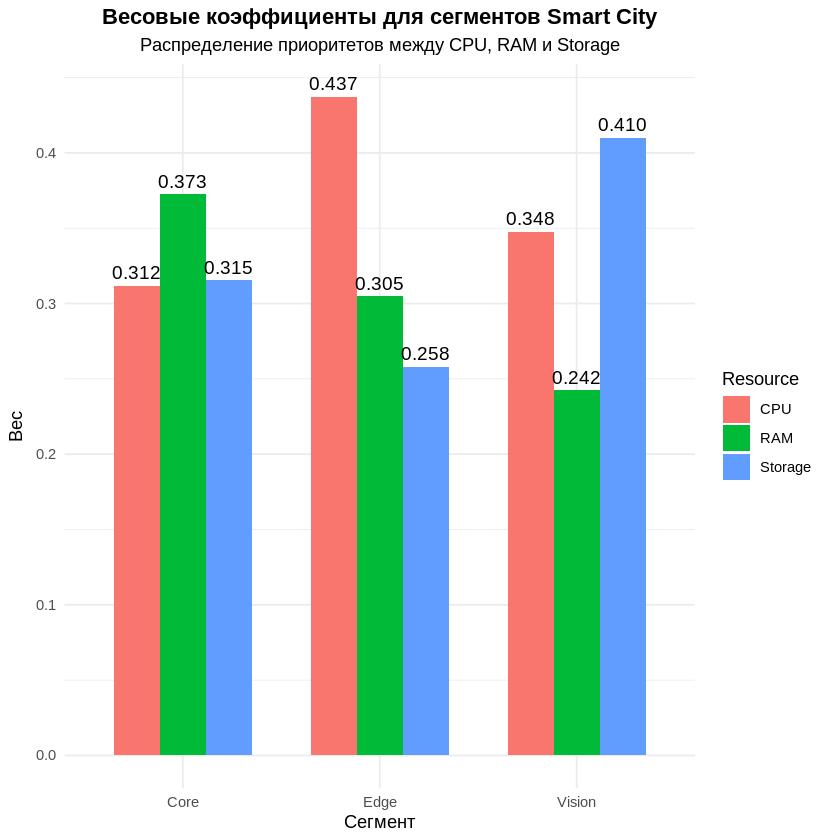

In [ ]:
# Визуализация весовых коэффициентов
weights_df <- data.frame(
  Segment = rep(c("Edge", "Core", "Vision"), each = 3),
  Resource = rep(c("CPU", "RAM", "Storage"), 3),
  Weight = c(edge_weights, core_weights, vision_weights)
)

ggplot(weights_df, aes(x = Segment, y = Weight, fill = Resource)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  geom_text(aes(label = sprintf("%.3f", Weight)),
            position = position_dodge(width = 0.7),
            vjust = -0.5, size = 4) +
  labs(title = "Весовые коэффициенты для сегментов Smart City",
       subtitle = "Распределение приоритетов между CPU, RAM и Storage",
       x = "Сегмент",
       y = "Вес") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5))

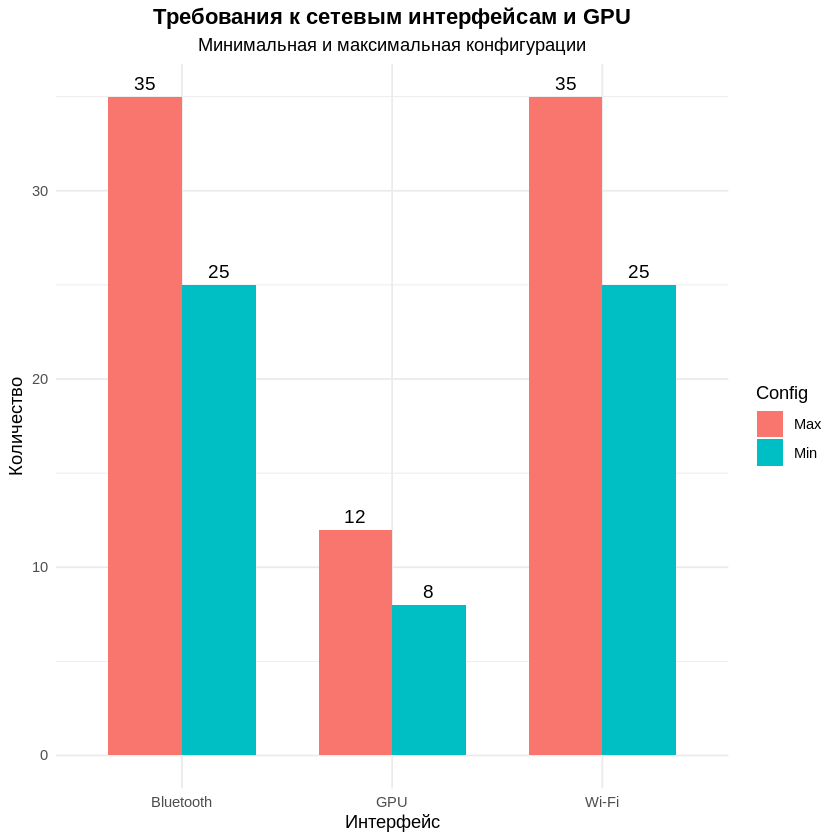

In [ ]:
# Визуализация сетевых требований
network_df <- data.frame(
  Interface = c("Wi-Fi", "Bluetooth", "GPU"),
  Min = c(min_totals$WiFi_Nodes, min_totals$BT_Nodes, min_totals$GPU_Count),
  Max = c(max_totals$WiFi_Nodes, max_totals$BT_Nodes, max_totals$GPU_Count)
)

network_long <- network_df %>%
  pivot_longer(cols = c(Min, Max),
               names_to = "Config",
               values_to = "Count")

ggplot(network_long, aes(x = Interface, y = Count, fill = Config)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  geom_text(aes(label = Count),
            position = position_dodge(width = 0.7),
            vjust = -0.5, size = 4) +
  labs(title = "Требования к сетевым интерфейсам и GPU",
       subtitle = "Минимальная и максимальная конфигурации",
       x = "Интерфейс",
       y = "Количество") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5))

---
## 18. Итоговые выводы

In [ ]:
cat("\n========================================\n")
cat("       ИТОГОВЫЕ ВЫВОДЫ ПО РАБОТЕ       \n")
cat("========================================\n\n")

cat("=== ЧАСТЬ 1: ПАРЕТО-ОПТИМИЗАЦИЯ ===\n\n")
cat(sprintf("1. Из 1000 конфигураций отобрано: %d\n", length(C)))
cat(sprintf("2. Парето-оптимальных решений: %d\n", length(result)))
cat(sprintf("3. Лучшая по идеальной точке: %s (расстояние: %.4f)\n", best_id, best_distance))
cat(sprintf("4. Лучшая по линейной свертке: %s (счет: %.4f)\n\n", best_weighted_id, best_weighted_score))

cat("=== ЧАСТЬ 2: МАСШТАБИРОВАНИЕ ===\n\n")
cat("1. Структура инфраструктуры Умного города включает 3 сегмента:\n")
cat(sprintf("   - Edge: %d-%d узлов\n", segments$Count_Min[1], segments$Count_Max[1]))
cat(sprintf("   - Core: %d-%d узлов\n", segments$Count_Min[2], segments$Count_Max[2]))
cat(sprintf("   - Vision: %d-%d узлов\n\n", segments$Count_Min[3], segments$Count_Max[3]))

cat("2. Суммарные ресурсы инфраструктуры:\n")
cat(sprintf("   - Минимум: CPU=%d, RAM=%.2f ТБ, Storage=%.2f ТБ, Цена=$%.0fK\n",
            min_totals$CPU, min_totals$RAM_TB, min_totals$Storage_TB, min_totals$Price_K))
cat(sprintf("   - Максимум: CPU=%d, RAM=%.2f ТБ, Storage=%.2f ТБ, Цена=$%.0fK\n\n",
            max_totals$CPU, max_totals$RAM_TB, max_totals$Storage_TB, max_totals$Price_K))

cat("3. Требования к сетевым интерфейсам:\n")
cat(sprintf("   - Wi-Fi 6: %d-%d узлов\n", min_totals$WiFi_Nodes, max_totals$WiFi_Nodes))
cat(sprintf("   - Bluetooth 5.0+: %d-%d узлов\n", min_totals$BT_Nodes, max_totals$BT_Nodes))
cat(sprintf("   - GPU: %d-%d\n\n", min_totals$GPU_Count, max_totals$GPU_Count))

cat("=== РЕКОМЕНДАЦИЯ ===\n")
cat("Для начального развёртывания рекомендуется конфигурация,\n")
cat("близкая к минимальной, с постепенным масштабированием.\n")
cat("========================================\n")


       ИТОГОВЫЕ ВЫВОДЫ ПО РАБОТЕ       

=== ЧАСТЬ 1: ПАРЕТО-ОПТИМИЗАЦИЯ ===

1. Из 1000 конфигураций отобрано: 82
2. Парето-оптимальных решений: 46
3. Лучшая по идеальной точке: PC-0957 (расстояние: 149.3089)
4. Лучшая по линейной свертке: PC-0871 (счет: 40.3601)

=== ЧАСТЬ 2: МАСШТАБИРОВАНИЕ ===

1. Структура инфраструктуры Умного города включает 3 сегмента:
   - Edge: 25-35 узлов
   - Core: 5-8 узлов
   - Vision: 8-12 узлов

2. Суммарные ресурсы инфраструктуры:
   - Минимум: CPU=386, RAM=1.90 ТБ, Storage=72.75 ТБ, Цена=$141K
   - Максимум: CPU=578, RAM=2.88 ТБ, Storage=110.25 ТБ, Цена=$216K

3. Требования к сетевым интерфейсам:
   - Wi-Fi 6: 25-35 узлов
   - Bluetooth 5.0+: 25-35 узлов
   - GPU: 8-12

=== РЕКОМЕНДАЦИЯ ===
Для начального развёртывания рекомендуется конфигурация,
близкая к минимальной, с постепенным масштабированием.
